**Customer Transaction Prediction Project**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("/content/train.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [4]:
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [ ]:
df.tail()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
199995,train_199995,0,11.4880,-0.4956,8.2622,3.5142,10.3404,11.6081,5.6709,15.1516,...,6.1415,13.2305,3.9901,0.9388,18.0249,-1.7939,2.1661,8.5326,16.6660,-17.8661
199996,train_199996,0,4.9149,-2.4484,16.7052,6.6345,8.3096,-10.5628,5.8802,21.5940,...,4.9611,4.6549,0.6998,1.8341,22.2717,1.7337,-2.1651,6.7419,15.9054,0.3388
199997,train_199997,0,11.2232,-5.0518,10.5127,5.6456,9.3410,-5.4086,4.5555,21.5571,...,4.0651,5.4414,3.1032,4.8793,23.5311,-1.5736,1.2832,8.7155,13.8329,4.1995
199998,train_199998,0,9.7148,-8.6098,13.6104,5.7930,12.5173,0.5339,6.0479,17.0152,...,2.6840,8.6587,2.7337,11.1178,20.4158,-0.0786,6.7980,10.0342,15.5289,-13.9001
199999,train_199999,0,10.8762,-5.7105,12.1183,8.0328,11.5577,0.3488,5.2839,15.2058,...,8.9842,1.6893,0.1276,0.3766,15.2101,-2.4907,-2.2342,8.1857,12.1284,0.1385


In [5]:
df.shape

(200000, 202)

In [6]:
df_copy = df.copy()

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


**The dataset contains 200 numerical features (float64), one target column (int64), and one identifier column (ID_code).**

In [7]:
print(df_copy.shape)

(200000, 202)


**The dataset contains 200,000 rows and 202 columns.**

In [8]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
target,200000.0,0.100490,0.300653,0.0000,0.000000,0.00000,0.000000,1.0000
var_0,200000.0,10.679914,3.040051,0.4084,8.453850,10.52475,12.758200,20.3150
var_1,200000.0,-1.627622,4.050044,-15.0434,-4.740025,-1.60805,1.358625,10.3768
var_2,200000.0,10.715192,2.640894,2.1171,8.722475,10.58000,12.516700,19.3530
var_3,200000.0,6.796529,2.043319,-0.0402,5.254075,6.82500,8.324100,13.1883
...,...,...,...,...,...,...,...,...
var_195,200000.0,-0.142088,1.429372,-5.2610,-1.170700,-0.17270,0.829600,4.2729
var_196,200000.0,2.303335,5.454369,-14.2096,-1.946925,2.40890,6.556725,18.3215
var_197,200000.0,8.908158,0.921625,5.9606,8.252800,8.88820,9.593300,12.0004
var_198,200000.0,15.870720,3.010945,6.2993,13.829700,15.93405,18.064725,26.0791


In [9]:
df_copy.isnull().sum()

,0
ID_code,0
target,0
var_0,0
var_1,0
var_2,0
...,...
var_195,0
var_196,0
var_197,0
var_198,0


In [10]:
missing_values = df_copy.isnull().sum()
print("Total Missing Values:", missing_values.sum())

Total Missing Values: 0


* There are no null values present in this dataset
* The dataset is complete and does not require missing value treatment.






In [11]:
df.isna().sum()

,0
ID_code,0
target,0
var_0,0
var_1,0
var_2,0
...,...
var_195,0
var_196,0
var_197,0
var_198,0


* No imputation techniques such as mean, median, or mode replacement were needed.
* No data cleaning is required.

In [12]:
duplicate_values= df_copy.duplicated().sum()
print("Total Duplicate Values:", duplicate_values)

Total Duplicate Values: 0


**No duplicate records were found in the dataset.**

In [13]:
df_copy['target'].value_counts()

,count
target,
0,179902
1,20098


The target variable is imbalanced.
* Class 0 (no transaction) has 1,79,902 records, while Class 1 (transaction) has 20,098 records.

In [14]:
df_copy['target'].value_counts(normalize=True) * 100

,proportion
target,
0,89.951
1,10.049


* Class 0 accounts for approximately 89.9% of the dataset, while
Class 1 accounts for around 10.049%.
* This indicates that only a small fraction of customers are actually performing transactions, while the majority do not.
* Due to this imbalance, the dataset may lead to biased model performance if accuracy is used as the only evaluation metric.
* Therefore, ROC-AUC score along with precision, recall, and F1-score will be used for evaluation.

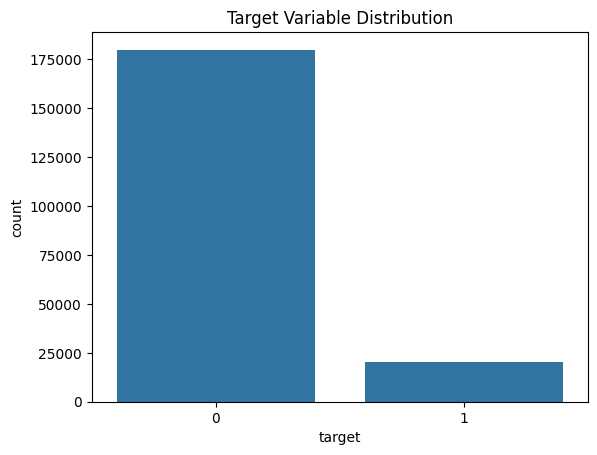

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df_copy)
plt.title("Target Variable Distribution")
plt.show()

* This confirms that only a small fraction of customers are actually performing transactions, while the majority do not.
* Due to this imbalance, the dataset may lead to biased model performance if accuracy is used as the only evaluation metric.
* Therefore, ROC-AUC score along with precision, recall, and F1-score will be used for evaluation.

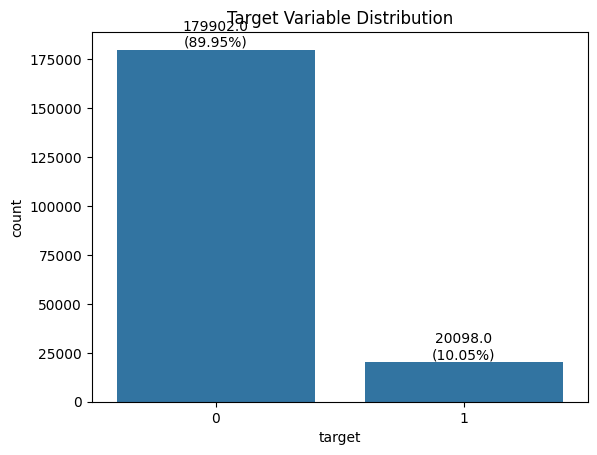

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

a = sns.countplot(x='target', data=df_copy)

total = len(df_copy)

for p in a.patches:
    count = p.get_height()
    percentage = 100 * count / total

    a.annotate(f'{count}\n({percentage:.2f}%)',
                (p.get_x() + p.get_width()/2., count),
                ha='center',
                va='bottom')

plt.title('Target Variable Distribution')
plt.show()

**This clearly demonstrates the 90:10 imbalance**

**Correlation Heatmap (Top Features)**

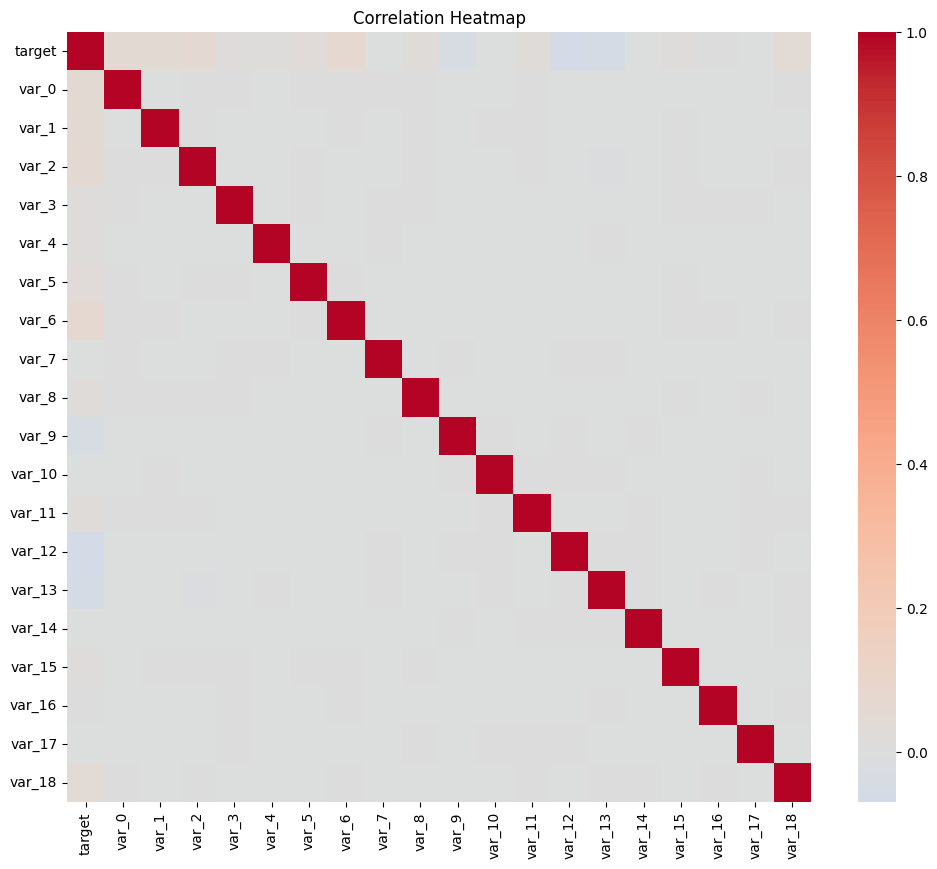

In [ ]:
plt.figure(figsize=(12,10))

corr = df_copy.iloc[:,1:21].corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()

* Low correlation indicates independent features.

- Separate the data, the input, and the target variables.

In [15]:
X = df_copy.drop(['ID_code', 'target'], axis=1)
y = df_copy['target']

- Split the training data and testing data 80-20 accordingly.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

- Find if there are NaN in the dataset.

In [17]:
print("NaNs in X_train:", pd.DataFrame(X_train).isnull().sum().sum())
print("NaNs in X_test:", pd.DataFrame(X_test).isnull().sum().sum())

NaNs in X_train: 0
NaNs in X_test: 0


- Scale the data.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- After scaling, check if there are NaN values present in the scaled data.

In [19]:
print("NaNs in X_train:", pd.DataFrame(X_train).isnull().sum().sum())
print("NaNs in X_test:", pd.DataFrame(X_test).isnull().sum().sum())

NaNs in X_train: 0
NaNs in X_test: 0


**Logistic Regression**

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)



LogisticRegression(max_iter=1000, random_state=42)

In [21]:
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9134
ROC-AUC: 0.8598618773835104

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     35980
           1       0.68      0.26      0.38      4020

    accuracy                           0.91     40000
   macro avg       0.80      0.62      0.66     40000
weighted avg       0.90      0.91      0.90     40000


Confusion Matrix:
[[35495   485]
 [ 2979  1041]]


* Accuracy = 91.34%, overall model perfomance. The model correctly predicts the 91.34% of the class.
* This alone can not be taken as the measure of performance, because the data is imbalanced.
* ROC-AUC = 85.98%, the model has a good ability to distinguish between customers who will make a transaction and those who will not.
* This score can be considered as a good performance.
* For class 0, the precision is 0.92, the recall is 0.99, and the F1 score is 0.95. The model is very good at identifying who will not make transactions.
* For class 1, the precision is 0.68, the recall is 0.26, and the F1 score is 0.38. - When the model predicts a transaction, it is correct 68% of the time. - The model detects only 26% of actual transaction customers.
* The model is failing to capture most of the customers who will actually make transactions.

**Logistic Regression Calss_weight="balanced"**

In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight="balanced")

lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [23]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))


Accuracy: 0.7834
ROC-AUC: 0.8598998891036755
              precision    recall  f1-score   support

           0       0.97      0.78      0.87     35980
           1       0.29      0.78      0.42      4020

    accuracy                           0.78     40000
   macro avg       0.63      0.78      0.64     40000
weighted avg       0.90      0.78      0.82     40000


Confusion Matrix:
[[28219  7761]
 [  903  3117]]


* Accuracy = 0.7834. Accuracy decreased because the model is no longer biased toward class 0.
* ROC-AUC = 0.8598. The model’s ability to separate classes did not change much.
* For class 1, Recall = 0.78. The model now correctly identifies 78% of actual transaction customers.
* For class 0, Recall = 0.78. The model's recall dropped from 0.99 to 0.78. More false positives for class 0.

After applying class_weight='balanced', the model became more sensitive towards the minority class (class 1). This significantly improved recall from 0.26 to 0.78, meaning the model is now able to identify a much higher proportion of customers who will make transactions. However, this improvement came at the cost of reduced performance on the majority class and lower overall accuracy.

In [ ]:
import pandas as pd
from IPython.display import display

# Show full text in DataFrame cells
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

# Create the table
data = {
    "Model": [
        "Logistic Regression (Normal)",
        "Logistic Regression (Balanced)"
    ],
    "Accuracy": [
        "0.91",
        "0.78"
    ],
     "ROC-AUC": [
        "0.859",
        "0.859"
    ],
    "Recall (Class 1)": [
        "0.26",
        "0.78"
    ]
}

df = pd.DataFrame(data)

# Display the table
display(df)

,Model,Accuracy,ROC-AUC,Recall (Class 1)
0,Logistic Regression (Normal),0.91,0.859,0.26
1,Logistic Regression (Balanced),0.78,0.859,0.78


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[28219  7761]
 [  903  3117]]


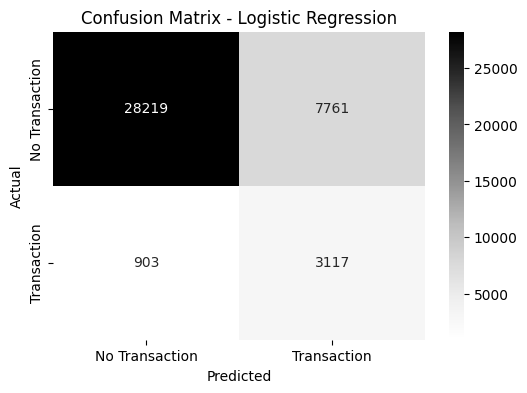

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greys',
    xticklabels=['No Transaction', 'Transaction'],
    yticklabels=['No Transaction', 'Transaction']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

The Logistic Regression model correctly classified 28,219 non-transaction customers and 3,117 transaction customers.
The model produced 7,761 false positives and 903 false negatives.
The relatively low number of false negatives indicates that the model successfully identifies a large proportion of customers who will make transactions, which is important for business applications where missing potential transaction customers can result in lost opportunities.

**Decision Tree**

In [24]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced'
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=20, min_samples_split=50,
                       random_state=42)

In [25]:
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.7261
ROC-AUC: 0.6408175285329882

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.83     35980
           1       0.17      0.46      0.25      4020

    accuracy                           0.73     40000
   macro avg       0.55      0.61      0.54     40000
weighted avg       0.85      0.73      0.77     40000


Confusion Matrix:
[[27187  8793]
 [ 2163  1857]]


The Decision Tree achieved an accuracy of 72.61% and a ROC-AUC score of 0.64. Although the model improved the identification of class 1 instances compared to the standard Logistic Regression model, it generated a large number of false positives and showed poor discrimination capability. The low ROC-AUC score indicates that the Decision Tree was unable to effectively separate transaction and non-transaction customers. Therefore, it is not suitable as the final production model for this dataset.

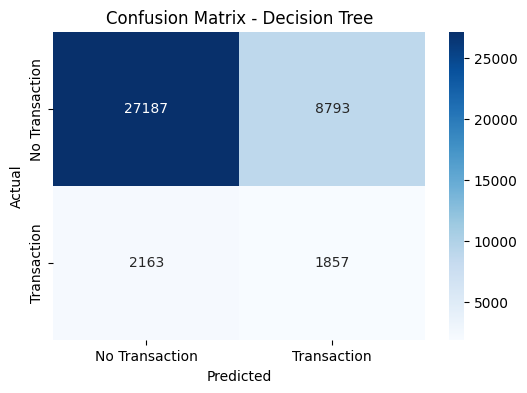

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Transaction', 'Transaction'],
    yticklabels=['No Transaction', 'Transaction']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

The confusion matrix shows that the Decision Tree model correctly classified 27,187 non-transaction customers and 1,857 transaction customers. However, it incorrectly predicted 8,793 non-transaction customers as transaction customers (false positives) and failed to identify 2,163 actual transaction customers (false negatives). This indicates that the model is effective in recognizing customers who do not make transactions, but is less reliable in identifying customers who do make transactions. The high number of false positives and false negatives suggests that the model's performance on the minority transaction class is limited, likely due to the imbalanced nature of the dataset.

**Random Forest**

In [26]:
from sklearn.ensemble import RandomForestClassifier
# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=20, min_samples_split=50, n_jobs=-1,
                       random_state=42)

In [27]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.84725
ROC-AUC: 0.7997847684866386

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.91     35980
           1       0.33      0.50      0.40      4020

    accuracy                           0.85     40000
   macro avg       0.63      0.69      0.65     40000
weighted avg       0.88      0.85      0.86     40000


Confusion Matrix:
[[31877  4103]
 [ 2007  2013]]


- The confusion matrix indicates that the Random Forest model correctly classified 31,877 customers who did not make a transaction (true negatives) and 2,013 customers who made a transaction (true positives). It incorrectly predicted 4,103 non-transaction customers as transaction customers (false positives) and failed to identify 2,007 actual transaction customers (false negatives).
- Compared with the Decision Tree model, Random Forest produced fewer false positives (4,103 vs. 8,793) and more true positives (2,013 vs. 1,857), demonstrating improved ability to distinguish between transaction and non-transaction customers.

Random Forest provides a more balanced model overall but misses a significant portion of actual transaction customers compared to Logistic Regression with class balancing.

The Random Forest model achieved an accuracy of 84.72% and a ROC-AUC score of 0.80. It significantly improved performance over the Decision Tree model, demonstrating better generalization and stability. However, when compared to Logistic Regression with class balancing, it showed lower recall for the minority class (0.50 vs 0.78), indicating reduced ability to identify customers who will make transactions. Therefore, while Random Forest provides balanced performance, Logistic Regression remains more suitable when prioritizing identification of potential transaction customers.

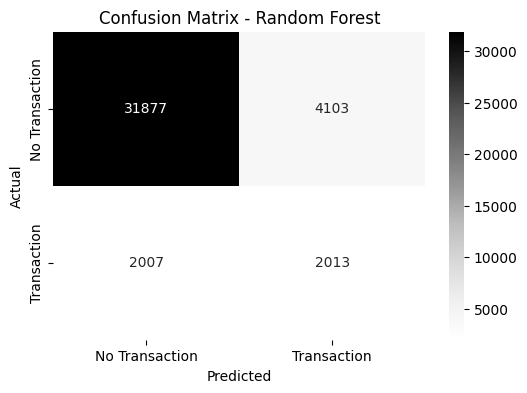

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greys',
    xticklabels=['No Transaction', 'Transaction'],
    yticklabels=['No Transaction', 'Transaction']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

**XGBOOST**

In [28]:
!pip install xgboost

In [29]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [30]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.913925
ROC-AUC: 0.8742822090215959

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     35980
           1       0.80      0.19      0.31      4020

    accuracy                           0.91     40000
   macro avg       0.86      0.59      0.63     40000
weighted avg       0.90      0.91      0.89     40000


Confusion Matrix:
[[35785   195]
 [ 3248   772]]


* The XGBoost model achieved the highest ROC-AUC score of 0.874, indicating strong ability to distinguish between customers who will and will not make transactions.
* But, the model showed very low recall for the class 1, meaning it failed to identify a large number of actual transaction customers.
* This suggests that while XGBoost is highly precise and effective for ranking customers, it is not optimal when the objective is to maximize detection of potential transaction customers.

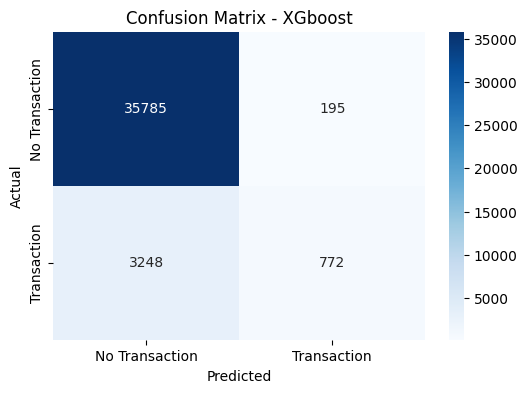

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Transaction', 'Transaction'],
    yticklabels=['No Transaction', 'Transaction']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGboost')
plt.show()

- The confusion matrix shows that the XGBoost model correctly classified 35,785 customers who did not make a transaction (true negatives) and 772 customers who made a transaction (true positives). It incorrectly predicted 195 non-transaction customers as transaction customers (false positives) and failed to identify 3,248 actual transaction customers (false negatives).
- These results indicate that the model is highly effective at identifying non-transaction customers and generates very few false alarms.
-  However, it misses a substantial number of actual transaction customers, making it less effective for detecting potential buyers.
-  Therefore, while XGBoost minimizes unnecessary marketing efforts, its ability to identify customers likely to make a transaction is limited.

**Gradient Boosting**

In [31]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=150, random_state=42)

In [32]:
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Accuracy: 0.9043
ROC-AUC: 0.8465803348460588

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     35980
           1       0.85      0.06      0.11      4020

    accuracy                           0.90     40000
   macro avg       0.88      0.53      0.53     40000
weighted avg       0.90      0.90      0.86     40000


Confusion Matrix:
[[35939    41]
 [ 3787   233]]


The Gradient Boosting model achieved an accuracy of 90.43% and a ROC-AUC score of 0.8466. While the model demonstrated very high precision for the class 1, its recall was extremely low, indicating that it failed to identify most customers who would make transactions. This suggests that the model prioritizes minimizing false positives over capturing all positive cases

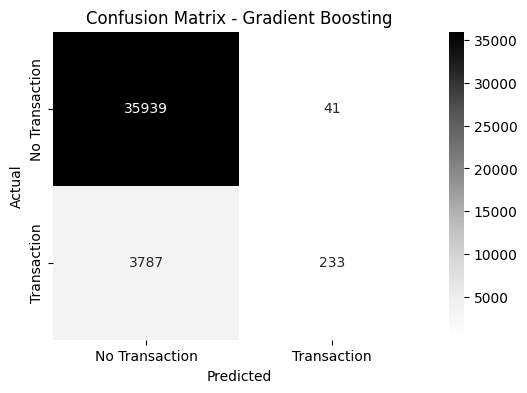

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greys',
    xticklabels=['No Transaction', 'Transaction'],
    yticklabels=['No Transaction', 'Transaction']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Gradient Boosting')
plt.show()

- The confusion matrix indicates that the Gradient Boosting model correctly classified 35,939 customers who did not make a transaction (true negatives) and 233 customers who made a transaction (true positives). It incorrectly predicted 41 non-transaction customers as transaction customers (false positives) and failed to identify 3,787 actual transaction customers (false negatives).
- These results show that the model is highly effective at identifying customers who are unlikely to make a transaction while generating almost no false alarms. However, it performs poorly in identifying actual transaction customers, missing a large proportion of potential buyers.
-  Therefore, despite its excellent performance on the majority class, the model is less suitable for customer transaction prediction when the primary objective is to identify customers likely to make transaction.

**Hyperparameter Tuning**

**Logistic Regression Tuning**

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [34]:
# Parameter Grid
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2'],
    'class_weight': ['balanced']
}


In [35]:
lr_hyper = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [36]:
lr_search_hyper = RandomizedSearchCV(
    estimator=lr_hyper,
    param_distributions=param_grid_lr,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    n_jobs=2,
    verbose=2,
    random_state=42
)

In [37]:
lr_search_hyper.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=LogisticRegression(max_iter=1000, random_state=42),
                   n_jobs=2,
                   param_distributions={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                                        'class_weight': ['balanced'],
                                        'penalty': ['l2'],
                                        'solver': ['liblinear', 'lbfgs']},
                   random_state=42, scoring='roc_auc', verbose=2)

In [38]:
# Best Parameters
print("Best Parameters:")
print(lr_search_hyper.best_params_)

print("\nBest ROC-AUC Score:")
print(lr_search_hyper.best_score_)

Best Parameters:
{'solver': 'liblinear', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.001}

Best ROC-AUC Score:
0.8585669344716399


In [39]:
best_lr = lr_search_hyper.best_estimator_

In [40]:
y_pred_hyper = best_lr.predict(X_test_scaled)

y_prob_hyper = best_lr.predict_proba(X_test_scaled)[:, 1]

In [ ]:
print("\nAccuracy:",
      accuracy_score(y_test, y_pred_hyper))

print("Precision:",
      precision_score(y_test, y_pred_hyper))

print("Recall:",
      recall_score(y_test, y_pred_hyper))

print("F1 Score:",
      f1_score(y_test, y_pred_hyper))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_hyper))


Accuracy: 0.777975
Precision: 0.2819592715528842
Recall: 0.7818407960199005
F1 Score: 0.4144524296169315
ROC-AUC: 0.8599140069524528


In [ ]:
cm_hyper = confusion_matrix(y_test, y_pred_hyper)

print("\nConfusion Matrix:")
print(cm_hyper)


Confusion Matrix:
[[27976  8004]
 [  877  3143]]


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_hyper))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.78      0.86     35980
           1       0.28      0.78      0.41      4020

    accuracy                           0.78     40000
   macro avg       0.63      0.78      0.64     40000
weighted avg       0.90      0.78      0.82     40000



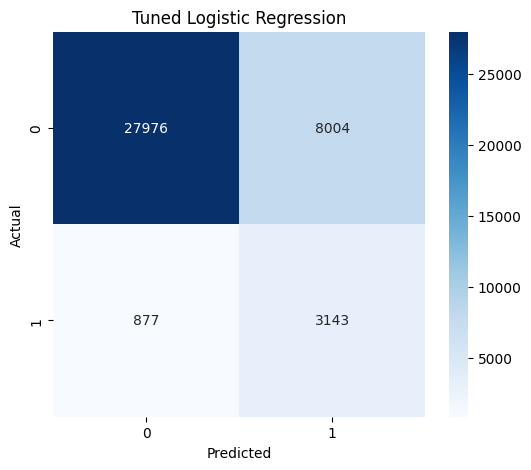

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_hyper,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Logistic Regression")

plt.show()

These results indicate that hyperparameter tuning did not improve the Logistic Regression model compared to your original balanced Logistic Regression.

| Metric           | Original Balanced LR | Tuned LR |
| ---------------- | -------------------- | -------- |
| ROC-AUC          | 0.8599               | 0.8599   |
| Recall (Class 1) | 0.78                 | 0.78     |
| Accuracy         | 0.7834               | 0.78     |
| Precision        | ~0.29                | 0.28     |
| F1 Score         | ~0.42                | 0.41     |
The numbers are essentially identical.

For this dataset:

* Features are already numerical.
* Relationships appear largely linear.
* Class imbalance is handled by class_weight='balanced'.

Why **Precision is Low** ?
* The model predicts many customers as potential transaction customers.
* This causes:
  Lower precision (28%)
  Higher recall (78%)
* This trade-off is expected when using:"class_weight='balanced'"


Hyperparameter tuning was performed on the Logistic Regression model using RandomizedSearchCV. The tuned model achieved a ROC-AUC score of 0.8599 and maintained a recall of approximately 78% for the transaction class. The results indicate that the original balanced Logistic Regression model was already near-optimal, and hyperparameter tuning produced only marginal changes in performance. Therefore, **Logistic Regression with class balancing** remained the preferred model due to its high recall, strong ROC-AUC, computational efficiency, and ease of deployment.

**XGBOOST Tuning**

In [41]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

In [42]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 8.95148650329643


In [43]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1],
    'min_child_weight': [1, 5],
    'scale_pos_weight': [scale_pos_weight]
}

In [44]:
xgb_hyper = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=2
)

In [45]:
xgb_search_hyper = RandomizedSearchCV(
    estimator=xgb_hyper,
    param_distributions=param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    n_jobs=2,
    verbose=2,
    random_state=42
)

In [46]:
xgb_search_hyper.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=2,
                                           num_parallel_tree=None, ...),
                   n_jobs=2,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'gamma': [0, 1],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'min_child_weight': [1, 5],
                                        'n_estimators': [100, 200],
                                        'scale_pos_weight': [8.95148650329643],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [47]:
best_xgb_hyper = xgb_search_hyper.best_estimator_

print("Best Parameters:")
print(xgb_search_hyper.best_params_)

print("\nBest ROC-AUC (CV):")
print(xgb_search_hyper.best_score_)

Best Parameters:
{'subsample': 1.0, 'scale_pos_weight': 8.95148650329643, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}

Best ROC-AUC (CV):
0.8596288887893012


In [48]:
y_pred_hyperXGB = best_xgb_hyper.predict(X_test)
y_prob_hyperXGB = best_xgb_hyper.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_hyperXGB))
print("Precision:", precision_score(y_test, y_pred_hyperXGB))
print("Recall:", recall_score(y_test, y_pred_hyperXGB))
print("F1 Score:", f1_score(y_test, y_pred_hyperXGB))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_hyperXGB))

cm_hyperXGB = confusion_matrix(y_test, y_pred_hyperXGB)
print("\nConfusion Matrix:\n", cm_hyperXGB)

print("\nClassification Report:\n", classification_report(y_test, y_pred_hyperXGB))

Accuracy: 0.81655
Precision: 0.3194776931447225
Recall: 0.7303482587064677
F1 Score: 0.4445117335352006
ROC-AUC: 0.8600080372180232

Confusion Matrix:
 [[29726  6254]
 [ 1084  2936]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.83      0.89     35980
           1       0.32      0.73      0.44      4020

    accuracy                           0.82     40000
   macro avg       0.64      0.78      0.67     40000
weighted avg       0.90      0.82      0.85     40000



Hyperparameter tuning significantly improved recall for the class 1 from 0.19 to 0.73, indicating a much better ability to identify potential transaction customers. However, this improvement came at the cost of reduced precision, demonstrating the expected trade-off between precision and recall in imbalanced classification problems.

In [ ]:
import pandas as pd

results_tuned = pd.DataFrame({
    'Model': ['Tuned Logistic Regression', 'Tuned XGBoost'],
    'Accuracy': [0.78, 0.82],
    'ROC-AUC': [0.8599, 0.86],
    'Precision (Class 1)': [0.28, 0.32],
    'Recall (Class 1)': [0.78, 0.73]
})

results_tuned

,Model,Accuracy,ROC-AUC,Precision (Class 1),Recall (Class 1)
0,Tuned Logistic Regression,0.78,0.8599,0.28,0.78
1,Tuned XGBoost,0.82,0.8600,0.32,0.73


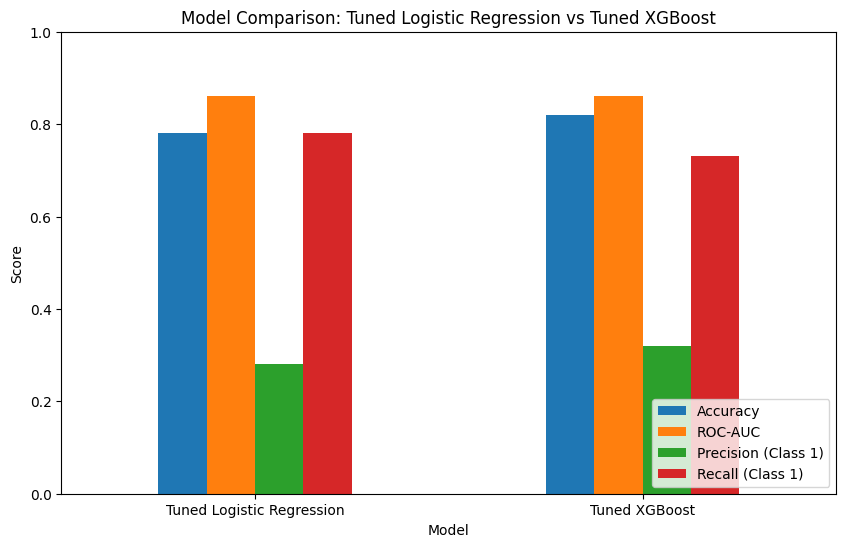

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

results_tuned.set_index('Model').plot(kind='bar', figsize=(10,6))

plt.title("Model Comparison: Tuned Logistic Regression vs Tuned XGBoost")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')

plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_hyper)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_hyperXGB)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

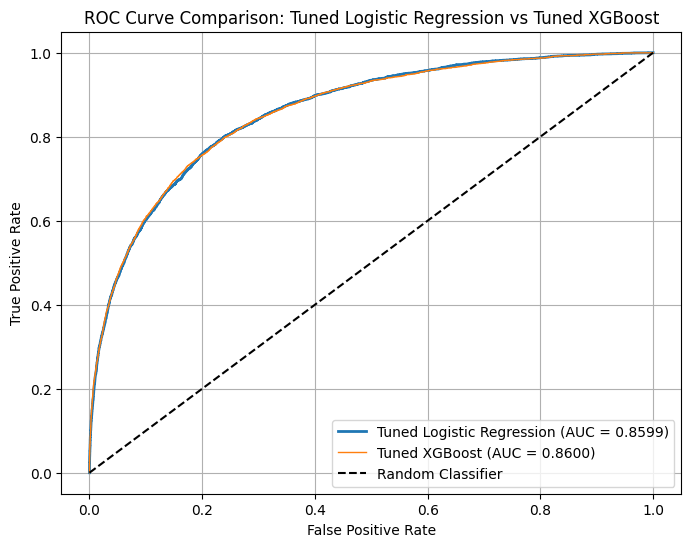

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Tuned Logistic Regression (AUC = {roc_auc_lr:.4f})',
    linewidth=2
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f'Tuned XGBoost (AUC = {roc_auc_xgb:.4f})',
    linewidth=1
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='black',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Tuned Logistic Regression vs Tuned XGBoost')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

The ROC curves of the tuned Logistic Regression and tuned XGBoost models show nearly identical performance, with ROC-AUC scores of approximately 0.86. While XGBoost achieved a marginally higher ROC-AUC and accuracy, Logistic Regression maintained higher recall for transaction customers. Therefore, Logistic Regression remained the preferred model because the primary business objective was to maximize identification of potential transaction customers.

**Precision-Recall Curve**

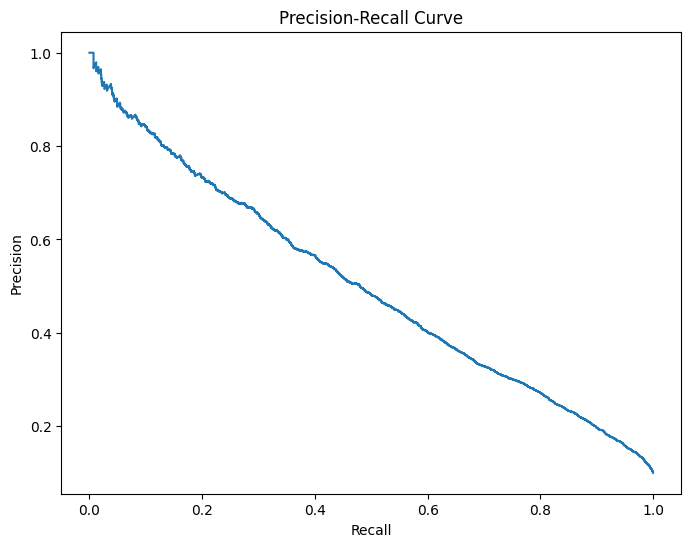

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

The above curve focuses on the minority class. Shows the trade-off between Precision and Recall.

**Matthews Correlation Coefficient (MCC)**

In [ ]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_test, y_pred)
print("Matthews Correlation Coefficient:", mcc)

Matthews Correlation Coefficient: 0.38529275714687544


The Matthews Correlation Coefficient for the selected model was 0.385.Matthews Correlation Coefficient is a balanced evaluation metric that considers true positives, true negatives, false positives, and false negatives, making it particularly suitable for imbalanced datasets. The obtained value indicates a moderate positive relationship between predicted and actual customer transaction outcomes, demonstrating that the model performs substantially better than random classification.

**Stochastic Gradient Descent Classifier[SGD Classifier]**

In [49]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss='log_loss',
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

sgd_model.fit(X_train_scaled, y_train)

SGDClassifier(class_weight='balanced', loss='log_loss', random_state=42)

In [50]:
y_pred_sgd = sgd_model.predict(X_test_scaled)
y_prob_sgd = sgd_model.predict_proba(X_test_scaled)[:, 1]

In [51]:
y_scores_sgd = sgd_model.decision_function(X_test_scaled)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_sgd))
print("Precision:", precision_score(y_test, y_pred_sgd))
print("Recall:", recall_score(y_test, y_pred_sgd))
print("F1 Score:", f1_score(y_test, y_pred_sgd))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_sgd))

cm = confusion_matrix(y_test, y_pred_sgd)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_sgd))

Accuracy: 0.76985
Precision: 0.2695111111111111
Recall: 0.7542288557213931
F1 Score: 0.3971185330713818
ROC-AUC: 0.845348023639446

Confusion Matrix:
[[27762  8218]
 [  988  3032]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.77      0.86     35980
           1       0.27      0.75      0.40      4020

    accuracy                           0.77     40000
   macro avg       0.62      0.76      0.63     40000
weighted avg       0.90      0.77      0.81     40000



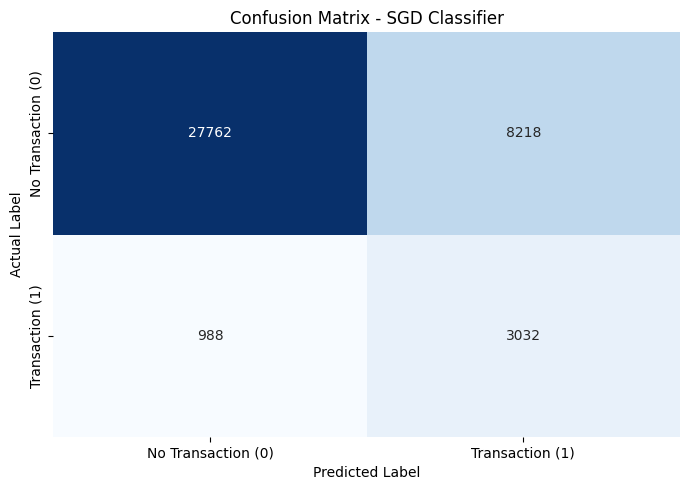

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm_sgd = confusion_matrix(y_test, y_pred_sgd)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_sgd,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['No Transaction (0)', 'Transaction (1)'],
    yticklabels=['No Transaction (0)', 'Transaction (1)']
)

plt.title('Confusion Matrix - SGD Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()
plt.show()

The SGD Classifier correctly identified 3,032 transaction customers and 27,762 non-transaction customers. The model achieved a Recall of 75%, indicating its ability to detect a large proportion of potential transaction customers. However, it generated 8,218 false positives, resulting in lower precision. Despite this limitation, the model demonstrated competitive performance and served as an effective large-scale classification benchmark.

The SGDClassifier was implemented as an additional linear classification model due to its computational efficiency and suitability for large datasets. The model achieved a Recall of 75% and a ROC-AUC score of 0.845, demonstrating competitive performance in identifying customers who will do transactions. However, its overall predictive performance remained slightly below that of the balanced Logistic Regression and tuned XGBoost models. Consequently, SGDClassifier was not selected as the final model but served as a useful benchmark for large-scale classification.

**Hyperparameter Tuning for SGDClassifier**

In [52]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'loss': ['log_loss', 'modified_huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [1000, 2000],
    'learning_rate': ['optimal'],
    'class_weight': ['balanced']
}

In [53]:
sgd_hyper = SGDClassifier(
    random_state=42
)

In [54]:
sgd_search_hyper = RandomizedSearchCV(
    estimator=sgd_hyper,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    n_jobs=2,
    verbose=2,
    random_state=42
)

In [55]:
sgd_search_hyper.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=SGDClassifier(random_state=42), n_jobs=2,
                   param_distributions={'alpha': [0.0001, 0.001, 0.01],
                                        'class_weight': ['balanced'],
                                        'learning_rate': ['optimal'],
                                        'loss': ['log_loss', 'modified_huber'],
                                        'max_iter': [1000, 2000],
                                        'penalty': ['l2', 'l1', 'elasticnet']},
                   random_state=42, scoring='roc_auc', verbose=2)

In [56]:
print("Best Parameters:")
print(sgd_search_hyper.best_params_)

print("\nBest ROC-AUC:")
print(sgd_search_hyper.best_score_)

Best Parameters:
{'penalty': 'elasticnet', 'max_iter': 1000, 'loss': 'log_loss', 'learning_rate': 'optimal', 'class_weight': 'balanced', 'alpha': 0.01}

Best ROC-AUC:
0.8579277112216274


In [57]:
best_sgd_hyper = sgd_search_hyper.best_estimator_

y_pred_sgd_hyper = best_sgd_hyper.predict(X_test_scaled)
y_prob_sgd_hyper = best_sgd_hyper.predict_proba(X_test_scaled)[:, 1]

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_sgd_hyper))
print("Precision:", precision_score(y_test, y_pred_sgd_hyper))
print("Recall:", recall_score(y_test, y_pred_sgd_hyper))
print("F1 Score:", f1_score(y_test, y_pred_sgd_hyper))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_sgd_hyper))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_sgd_hyper))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_sgd_hyper))

Accuracy: 0.783775
Precision: 0.2869765301426599
Recall: 0.7756218905472637
F1 Score: 0.4189452468928451
ROC-AUC: 0.8598484439945907

Confusion Matrix:
[[28233  7747]
 [  902  3118]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.78      0.87     35980
           1       0.29      0.78      0.42      4020

    accuracy                           0.78     40000
   macro avg       0.63      0.78      0.64     40000
weighted avg       0.90      0.78      0.82     40000



- The confusion matrix shows that the tuned SGD Classifier correctly classified 28,233 customers who did not make a transaction (true negatives) and 3,118 customers who made a transaction (true positives). It incorrectly predicted 7,747 non-transaction customers as transaction customers (false positives) and failed to identify 902 actual transaction customers (false negatives).
- Compared with the Decision Tree, Random Forest, XGBoost, and Gradient Boosting models, the tuned SGD Classifier achieved the highest number of true positives and the lowest number of false negatives, demonstrating superior ability to identify customers who are likely to make a transaction.

Hyperparameter tuning substantially improved the performance of the SGDClassifier. The tuned model achieved a ROC-AUC score of 0.859 and a Recall of 78%, matching the performance of the balanced Logistic Regression model. Additionally, SGDClassifier offers faster training and lower computational requirements, making it a scalable alternative for large datasets. However, it did not provide a significant performance advantage over Logistic Regression.

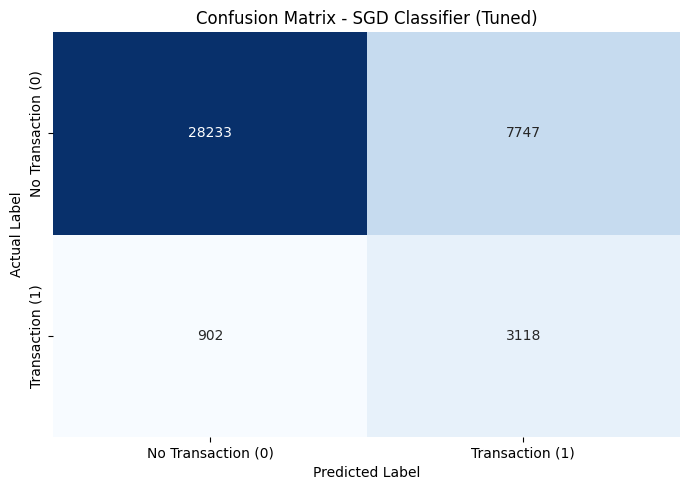

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm_sgd = confusion_matrix(y_test, y_pred_sgd_hyper)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_sgd,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['No Transaction (0)', 'Transaction (1)'],
    yticklabels=['No Transaction (0)', 'Transaction (1)']
)

plt.title('Confusion Matrix - SGD Classifier (Tuned)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()
plt.show()

**Model Comparison**

In [ ]:
import pandas as pd
from IPython.display import display

# Show full text in DataFrame cells
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

# Create the table
data = {
    "Model": [
        "Logistic Regression (Normal)",
        "Logistic Regression (Balanced)",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Gradient Boosting",
        "Logistic Regression (Tuned)",
        "XGBoost(Tuned)",
        "Stochastic Gradient Descent Classifier",
        "Stochastic Gradient Descent Classifier(tuned)"
    ],
    "Accuracy": [
        "0.91",
        "0.78",
        "0.72",
        "0.84",
        "0.91",
        "0.90",
        "0.78",
        "0.82",
        "0.76",
        "0.78"
    ],
     "ROC-AUC": [
        "0.859",
        "0.859",
        "0.640",
        "0.799",
        "0.874",
        "0.846",
        "0.8599",
        "0.86",
        "0.845",
        "0.859"
    ],
    "Precision (Class 1)":[
        "0.68",
        "0.29",
        "0.17",
        "0.33",
        "0.80",
        "0.85",
        "0.28",
        "0.32",
        "0.27",
        "0.29"
    ],
    "Recall (Class 1)":[
        "0.26",
        "0.78",
        "0.46",
        "0.50",
        "0.19",
        "0.06",
        "0.78",
        "0.73",
        "0.75",
        "0.78"
    ],
    "Key Observation": [
        "High accuracy but poor detection of transactions",
        "Best at identifying transaction customers",
        "Weak Performance and overfitting issues",
        "Balanced performance but moderate ROC-AUC",
        "Best ROC-AUC, strong ranking ability",
        "Very high precision but extremely low recall",
        "No Change",
        "Improvement in recall",
        "Achieved high Recall (75%) and demonstrated efficient training on large datasets",
        "Substantially improved the performance"
    ]

}

df = pd.DataFrame(data)
def highlight_max(s):
    return ['background-color: lightblue' if v == s.max() else '' for v in s]

styled_df = df.style.apply(highlight_max, subset=["Accuracy", "ROC-AUC","Precision (Class 1)","Recall (Class 1)"])

# Display the table
display(styled_df)



,Model,Accuracy,ROC-AUC,Precision (Class 1),Recall (Class 1),Key Observation
0,Logistic Regression (Normal),0.91,0.859,0.68,0.26,High accuracy but poor detection of transactions
1,Logistic Regression (Balanced),0.78,0.859,0.29,0.78,Best at identifying transaction customers
2,Decision Tree,0.72,0.640,0.17,0.46,Weak Performance and overfitting issues
3,Random Forest,0.84,0.799,0.33,0.50,Balanced performance but moderate ROC-AUC
4,XGBoost,0.91,0.874,0.80,0.19,"Best ROC-AUC, strong ranking ability"
5,Gradient Boosting,0.90,0.846,0.85,0.06,Very high precision but extremely low recall
6,Logistic Regression (Tuned),0.78,0.8599,0.28,0.78,No Change
7,XGBoost(Tuned),0.82,0.86,0.32,0.73,Improvement in recall
8,Stochastic Gradient Descent Classifier,0.76,0.845,0.27,0.75,Achieved high Recall (75%) and demonstrated efficient training on large datasets
9,Stochastic Gradient Descent Classifier(tuned),0.78,0.859,0.29,0.78,Substantially improved the performance


* **XGBoost** achieved the highest ROC-AUC score (0.874), **making it the best model for ranking customers based on their likelihood of making a transaction.**
* **Logistic Regression** (Balanced) achieved the highest recall for Class 1 (0.78), **making it the best model for identifying as many potential transaction customers as possible.**
* Tree-based models like Random Forest and Gradient Boosting provided balanced performance but were less effective in capturing the class 1.
* Stochastic Gradient Descent Classifier(tuned) substantially improved the performance.

**Final Conclusion**

The Customer Transaction Prediction project aimed to identify customers who are likely to perform future transactions using a highly imbalanced dataset containing 200,000 records and 202 anonymized numerical features.

Multiple machine learning models, including Logistic Regression, Decision Tree, Random Forest, XGBoost, Gradient Boosting and SGDClassifier, were developed and evaluated. Since the primary objective of the project is to identify customers who are likely to make future transactions, Recall for the positive class (Class 1) was considered the most important evaluation metric.

Among all models tested, Logistic Regression with class balancing achieved the highest Recall (0.78) while maintaining a strong ROC-AUC score of approximately 0.86. Although tuned XGBoost achieved slightly higher Accuracy, Precision, and overall ROC-AUC, its Recall was lower than that of Logistic Regression. The tuned SGDClassifier achieved
performance comparable to Logistic Regression but did not provide a significant improvement.

Therefore, **Logistic Regression with class_weight='balanced'** was selected as the **final model**, as it best aligns with the business objective of identifying the maximum number of potential transaction customers while remaining computationally efficient and easy to interpret.

The final model can help financial institutions improve customer targeting, optimize marketing campaigns, and support data-driven decision-making by effectively identifying customers with a high likelihood of future transactions.

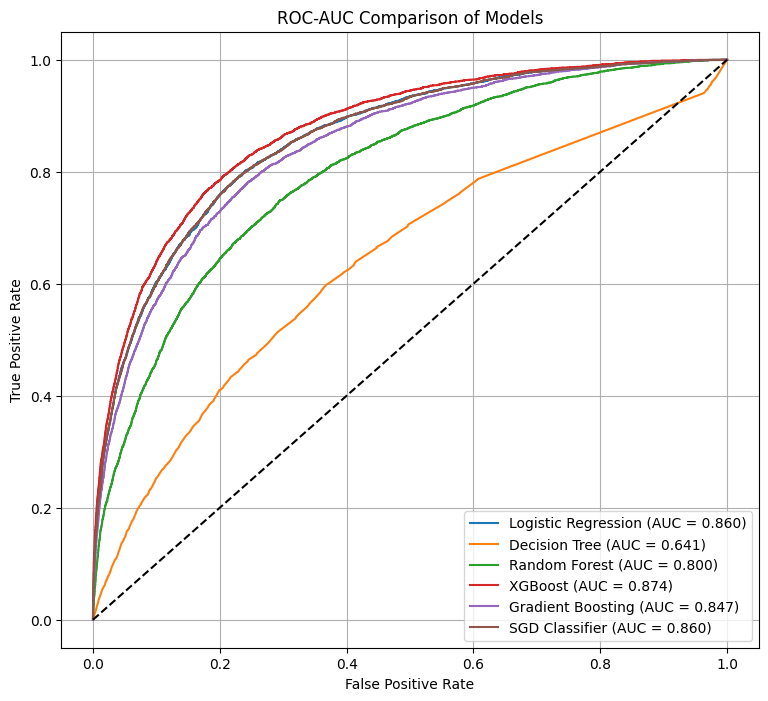

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Logistic Regression (Balanced)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_lr = auc(fpr_lr, tpr_lr)

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_dt = auc(fpr_dt, tpr_dt)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_rf = auc(fpr_rf, tpr_rf)

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_gb = auc(fpr_gb, tpr_gb)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_xgb = auc(fpr_xgb, tpr_xgb)

#SGD Classifier Tuned
fpr_sgd, tpr_sgd, _ = roc_curve(y_test, y_prob_sgd_hyper)
roc_sgd = auc(fpr_sgd, tpr_sgd)

plt.figure(figsize=(9,8))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_dt:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_xgb:.3f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_gb:.3f})')
plt.plot(fpr_sgd, tpr_sgd, label=f'SGD Classifier (AUC = {roc_sgd:.3f})')

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.title('ROC-AUC Comparison of Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

The ROC-AUC curves shows that XGBoost and Logistic Regression (balanced) perform the best in distinguishing between transaction and non-transaction customers. XGBoost achieves the highest overall AUC, while Logistic Regression provides a strong balance between discrimination and recall.

**Calculate MCC for each model**

In [60]:
from sklearn.metrics import matthews_corrcoef

# Logistic Regression
mcc_lr = matthews_corrcoef(y_test, y_pred)

# Logistic Regression (Balanced)
mcc_lr_bal = matthews_corrcoef(y_test, y_pred_lr)

# Logistic Regression (Tuned)
mcc_lr_tuned = matthews_corrcoef(y_test, y_pred_hyper)

# Decision Tree
mcc_dt = matthews_corrcoef(y_test, y_pred_dt)

# Random Forest
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)

# Gradient Boosting
mcc_gb = matthews_corrcoef(y_test, y_pred_gb)

# XGBoost
mcc_xgb = matthews_corrcoef(y_test, y_pred_xgb)

# XGBoost (Tuned)
mcc_xgb_tuned = matthews_corrcoef(y_test, y_pred_hyperXGB)

# SGD Classifier
mcc_sgd = matthews_corrcoef(y_test, y_pred_sgd)

# SGD Classifier (Tuned)
mcc_sgd_tuned = matthews_corrcoef(y_test, y_pred_sgd_hyper)

In [61]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression (Balanced)",
        "Logistic Regression (Tuned)",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "XGBoost (Tuned)",
        "SGD Classifier",
        "SGD Classifier (Tuned)"
    ],
    "MCC": [
        mcc_lr,
        mcc_lr_bal,
        mcc_lr_tuned,
        mcc_dt,
        mcc_rf,
        mcc_gb,
        mcc_xgb,
        mcc_xgb_tuned,
        mcc_sgd,
        mcc_sgd_tuned
    ]
})

results["MCC"] = results["MCC"].round(4)
results

,Model,MCC
0,Logistic Regression,0.3853
1,Logistic Regression (Balanced),0.3782
2,Logistic Regression (Tuned),0.3751
3,Decision Tree,0.1480
4,Random Forest,0.3231
5,Gradient Boosting,0.2071
6,XGBoost,0.3653
7,XGBoost (Tuned),0.3978
8,SGD Classifier,0.3516
9,SGD Classifier (Tuned),0.3787


The Matthews Correlation Coefficient (MCC) was used to evaluate the overall quality of classification while accounting for all four outcomes of the confusion matrix: true positives, true negatives, false positives, and false negatives. Since the dataset is highly imbalanced, MCC provides a more reliable measure of model performance than accuracy alone.

XGBoost (Tuned) achieved the highest MCC (0.3978), indicating the strongest overall balance between correctly classifying transaction and non-transaction customers.
Logistic Regression achieved an MCC of 0.3853, showing strong and balanced predictive.

Although XGBoost (Tuned) achieved the highest Matthews Correlation Coefficient (MCC), its recall for the transaction class (Class 1) was significantly lower than that of the balanced Logistic Regression model. Since the primary business objective of this project is to identify as many future transaction customers as possible, Recall was considered the most important evaluation metric. Therefore, **Logistic Regression with class_weight='balanced'** was selected as the **final model for predicting future customer transactions**.

#### Comparison plot of Machine Learning Models

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

# ===========================
# Calculate evaluation metrics
# ===========================

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Logistic Regression (Balanced)',
        'Logistic Regression (Tuned)',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'XGBoost (Tuned)',
        'SGD Classifier',
        'SGD Classifier (Tuned)'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_hyper),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_hyperXGB),
        accuracy_score(y_test, y_pred_sgd),
        accuracy_score(y_test, y_pred_sgd_hyper)
    ],

    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_hyper),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_hyperXGB),
        precision_score(y_test, y_pred_sgd),
        precision_score(y_test, y_pred_sgd_hyper)
    ],

    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_hyper),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_hyperXGB),
        recall_score(y_test, y_pred_sgd),
        recall_score(y_test, y_pred_sgd_hyper)
    ],

    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_hyper),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_hyperXGB),
        f1_score(y_test, y_pred_sgd),
        f1_score(y_test, y_pred_sgd_hyper)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_pred_hyper),
        roc_auc_score(y_test, y_pred_dt),
        roc_auc_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_pred_gb),
        roc_auc_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_pred_hyperXGB),
        roc_auc_score(y_test, y_pred_sgd),
        roc_auc_score(y_test, y_pred_sgd_hyper)
    ],

    'MCC': [
        matthews_corrcoef(y_test, y_pred),
        matthews_corrcoef(y_test, y_pred_lr),
        matthews_corrcoef(y_test, y_pred_hyper),
        matthews_corrcoef(y_test, y_pred_dt),
        matthews_corrcoef(y_test, y_pred_rf),
        matthews_corrcoef(y_test, y_pred_gb),
        matthews_corrcoef(y_test, y_pred_xgb),
        matthews_corrcoef(y_test, y_pred_hyperXGB),
        matthews_corrcoef(y_test, y_pred_sgd),
        matthews_corrcoef(y_test, y_pred_sgd_hyper)
    ]
})

# Round values
results = results.round(4)



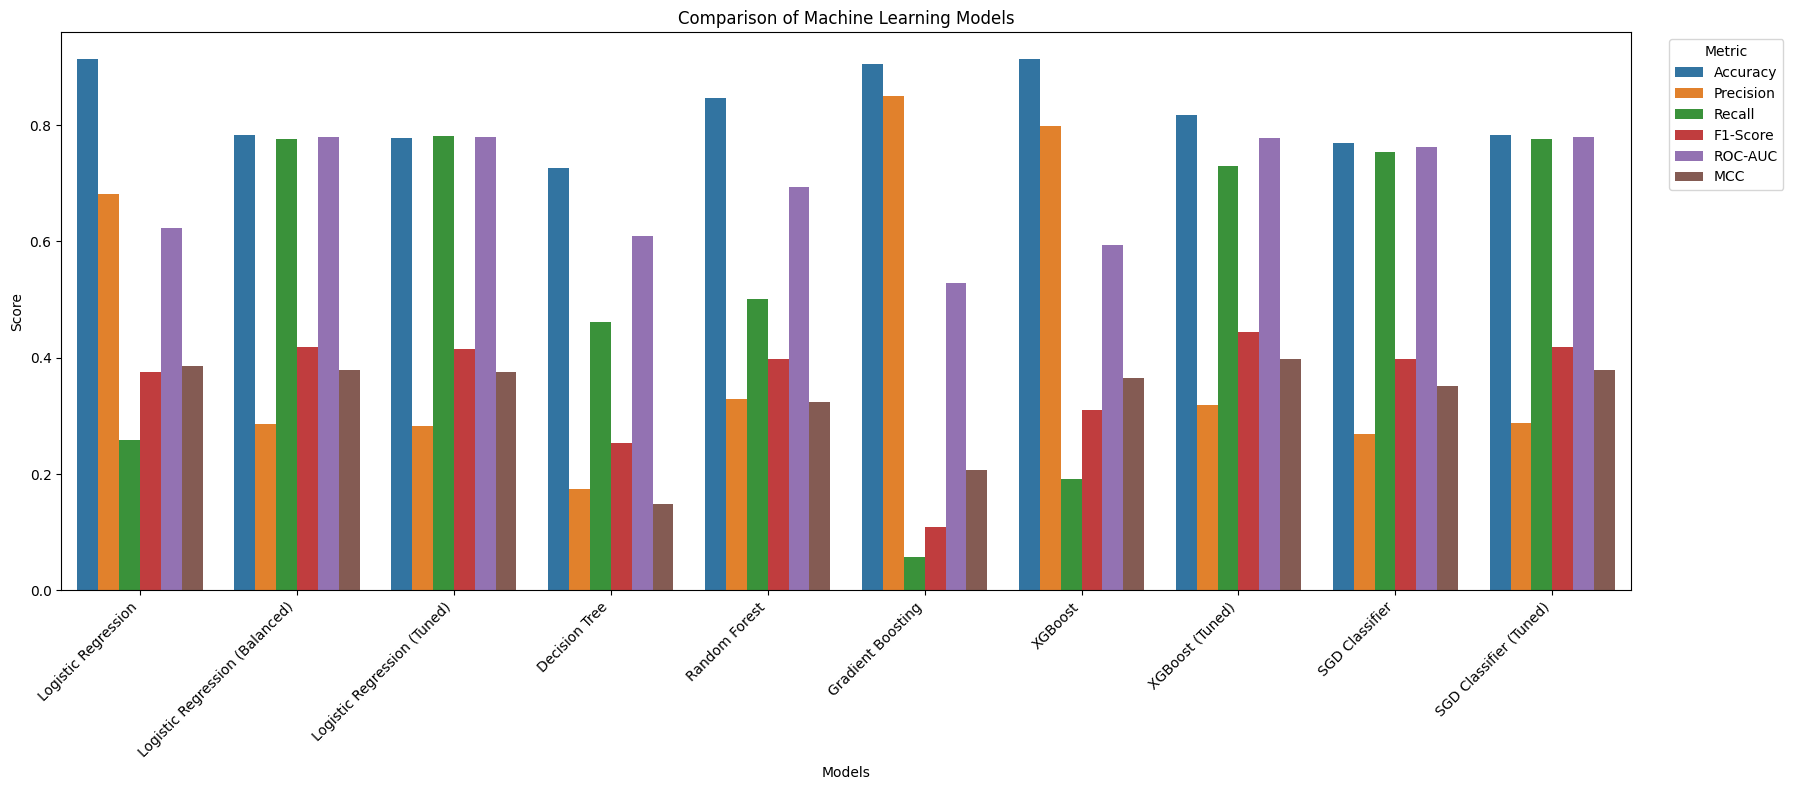

In [64]:
# Convert to long format
results_long = results.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(18,8))

sns.barplot(
    data=results_long,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()

plt.show()

The comparison plot demonstrates that no single model performs best across all evaluation metrics. While XGBoost (Tuned) achieved the highest MCC and XGBoost obtained high accuracy, Logistic Regression with class_weight='balanced' achieved the highest recall for the transaction class, which is the most important metric for this project. Since the primary business objective is to identify as many future transaction customers as possible, Logistic Regression (Balanced) was selected as the final model despite not having the highest overall accuracy or MCC.

**Save the Logistic regression with class balanced model for deployment**

In [ ]:
import joblib

joblib.dump(lr, "transaction_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

### PROJECT REPORT

#### Project Overview

Customer transaction prediction is a critical problem in banking and financial services because identifying customers who are likely to perform future transactions enables organizations to optimize marketing efforts, improve customer engagement, and increase revenue generation.
The objective of this project is to develop a predictive model that can identify whether a customer will make a transaction in the future. The dataset consists of anonymized customer information with 200 numerical features, an ID column, and a target variable. The target variable contains binary values where:

- 0 = Customer will not make a transaction
- 1 = Customer will make a transaction
  
Since the target variable has two classes, this is a binary classification problem.


#### Business Problem Statement

In the banking and financial services sector, understanding customer behaviour is essential for developing effective customer relationship management and marketing strategies. Financial institutions generate large volumes of customer data through various interactions and transactions; however, identifying customers who are likely to engage in future transaction activities remains a significant analytical challenge.

Traditional customer outreach programs often rely on broad segmentation approaches that may not accurately distinguish between customers with high and low transaction potential. As a result, organizations may incur unnecessary operational and marketing costs while achieving suboptimal campaign effectiveness.

Specifically, the project seeks to:

- Develop a robust binary classification model to predict future customer transaction behaviour.
- Evaluate the effectiveness of multiple machine learning algorithms on an imbalanced dataset.
- Improve the identification of potential transaction customers through appropriate model selection and evaluation metrics.
- Support data-driven customer targeting and decision-making processes.
- Provide insights that can assist financial institutions in optimizing resource allocation and customer engagement strategies.

The successful implementation of such a predictive framework can enable organizations to proactively identify high-potential customers, improve the efficiency of marketing initiatives, and enhance overall business performance through informed decision-making.


#### Data Understanding

**Dataset Information**
-	Total Records: 200,000
-	Total Features: 200 numerical variables
-	Additional Columns:
    -	ID_code
    -	target
    
**Data Types**
-	200 Float Features
-	1 Integer Feature (target)
-	1 Object Feature (ID_code)

**Target Variable Distribution**

Target Distribution:
-	Class 0: 179,902 records
-	Class 1: 20,098 records


#### Data Quality Check

Observations:

- No missing values
- No categorical variables
- No duplicate target issues
- Data is clean and preprocessed


#### Exploratory Data Analysis (EDA)

**Target Distribution Analysis**

**Target variable distribution:**

In [ ]:

import pandas as pd

# Create the DataFrame
class_distribution = pd.DataFrame({
    'Class': [0, 1],
    'Count': [179902, 20098]
})

# Display the table
class_distribution


,Class,Count
0,0,179902
1,1,20098


**Percentage Distribution**
-	Class 0 = 89.95%
-	Class 1 = 10.05%

Impact:

- Model bias toward the majority class
- High accuracy can be misleading
- Minority class harder to predict
- Recall becomes more important than accuracy

Since we have anonymized features, there is very little scope for EDA.

Feature-level business interpretation is not possible

EDA is limited to:
- Distribution analysis
- Target imbalance check
- Statistical summaries
  
Key Insight:
- No categorical features
- No interpretable feature names
- Feature importance is model-driven, not domain-driven

#### Observation

The dataset is significantly imbalanced, with approximately 90% of observations belonging to the non-transaction class.

This imbalance presents several challenges:
-	Models may become biased toward the majority class.
-	High accuracy may be misleading.
-	Minority class prediction becomes difficult.
-	False negatives become more likely.

Therefore, evaluation metrics such as Recall, F1-score, and ROC-AUC become more important than Accuracy.


#### Feature Analysis

The dataset contains 200 anonymized numerical variables.

Observations:
-	No categorical variables exist.
-	Features are already anonymized.
-	No domain-specific interpretation is available.
-	All features are continuous numerical values.

Because feature names are anonymized, **model performance becomes more important than feature-level business interpretation.**


#### Data Preprocessing

The following preprocessing steps were performed:

1.	Removed ID_code column.
2.	Split the dataset into training and testing sets using an 80:20 ratio.
3.	Applied Standard Scaling for Logistic Regression.
4.	Used class balancing techniques where appropriate to address class imbalance.
    
To address severe class imbalance, class_weight='balanced' was applied.

This technique automatically adjusts weights according to:

**Weight = Total Samples / (Number of Classes × Class Frequency)**

Benefits:
-	Increases attention to the minority class.
-	Improves recall.
-	Reduces majority class bias.



#### Model Building

The following machine learning algorithms were implemented:
    
1.	Logistic Regression
2.	Logistic Regression (Balanced)
3.	Logistic Regression with Hyperparameter Tuning
4.	Decision Tree
5.	Random Forest
6.	Gradient Boosting
7.	XGBoost
8.	XGBoost with Hyperparameter Tuning
9.	SGD Classifier
10.	SGD Classifier with Hyperparameter Tuning

Models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- Matthews Correlation Coefficient (MCC)
- Cross-validation (ROC-AUC)



| Model                          | ROC-AUC | Recall (Class 1) | Observation               |
| ------------------------------ | ------- | ---------------- | ------------------------- |
| Logistic Regression (Balanced) | ~0.86   | **0.78**         | Best recall               |
| SGD Classifier (Tuned)         | ~0.86   | **0.78**         | High recall, less stable  |
| Random Forest                  | 0.79    | 0.50             | Balanced performance      |
| Decision Tree                  | 0.64    | 0.46             | Weak model                |
| XGBoost                        | 0.87    | 0.19             | High accuracy, low recall |
| Gradient Boosting              | 0.85    | 0.06             | Very poor recall          |


#### Confusion Matrix Insight (Key Finding)

Best models (Logistic Regression and SGD):

- High True Positives --> good customer identification
- Moderate False Positives --> acceptable trade-off
- Low False Negatives --> critical business advantage

Worst models (Boosting models):

- High accuracy but poor minority detection
- Strong bias toward non-transaction class

#### Model Comparison and Model Interpretability

Model interpretability refers to the ability to understand how a machine learning model makes predictions and which factors contribute to its decisions. In business applications, interpretability is important because stakeholders often need to understand and trust the model's recommendations before integrating them into decision-making processes.

In this project, multiple models with varying levels of interpretability were evaluated:


#### Logistic Regression

Logistic Regression predicts class probabilities using the sigmoid function.

**Advantages**:
-	Fast training
-	Easy interpretation
-	Good baseline model
-	Low computational cost

**Limitations**:
-	Assumes linear decision boundary


- Accuracy = 91.34%, overall model perfomance. The model correctly predicts the 91.34% of the class.
- This alone can not be taken as the measure of performance, because the data is imbalanced.
- ROC-AUC = 85.98%, the model has a good ability to distinguish between customers who will make a transaction and those who will not.
- This score can be considered as a good performance.
- For class 0, the precision is 0.92, the recall is 0.99, and the F1 score is 0.95. The model is very good at identifying who will not make transactions.
- For class 1, the precision is 0.68, the recall is 0.26, and the F1 score is 0.38. - When the model predicts a transaction, it is correct 68% of the time.
- The model detects only 26% of actual transaction customers.
- The model is failing to capture most of the customers who will actually make transactions.

#### Logistic Regression (Balanced)

This model uses:
class_weight='balanced'

**Advantages**:
-	Handles class imbalance effectively.
-	Significantly improves minority class detection.
-	Maintains strong ROC-AUC performance.



Our tuned Logistic Regression is doing exactly what we want for this project:

-	Correctly identifies 3,117 transaction customers (True Positives).
-	Correctly identifies 28,219 non-transaction customers (True Negatives).
-	Achieves a high recall of approximately 78%, indicating strong ability to detect customers who are likely to make a transaction.

Since the business objective is:
Identify as many future transaction customers as possible

**This is a strong result.**

#### Logistic regression (Tuned)

After performing hyperparameter tuning on the Logistic Regression model using RandomizedSearchCV, no significant improvement was observed in model performance. The ROC-AUC score remained approximately 0.86, and recall for the minority class remained stable at around 78%.

##### Conclusion

This indicates that the baseline Logistic Regression model with class_weight='balanced' was already near-optimal for this dataset. Since Logistic Regression is a linear model with limited hyperparameters, tuning parameters such as regularization strength (C) and solver had minimal impact on the decision boundary.

**Therefore, the original balanced Logistic Regression model was retained as the final model due to its simplicity, stability, and strong recall performance.**


#### Decision Tree

**Description**
  
Decision Tree recursively splits data based on feature thresholds.
    
Advantages:
-	Easy to visualize
-	Handles nonlinear relationships
-	Requires minimal preprocessing

Limitations:
-	Prone to overfitting
-	Sensitive to data variations


The Decision Tree model showed the weakest performance among all evaluated models, with a low ROC-AUC of 0.64 and poor Precision (0.17) for the positive class. Although Recall (0.46) was moderate, the model suffered from overfitting and unstable predictions, **making it unsuitable** for reliable customer transaction prediction compared to ensemble and linear models.

#### Random Forest

**Description**
  
Random Forest combines multiple Decision Trees using bagging.
    
Advantages:
-	Reduces overfitting
-	Better generalization
-	Handles nonlinear patterns

Limitations:
-	Less interpretable
-	Higher computational cost

The Random Forest model showed improved performance compared to the Decision Tree, achieving an ROC-AUC of 0.799 and better overall stability due to ensemble learning. However, its Recall (0.50) remained significantly lower than Logistic Regression with class balancing, indicating that it missed a considerable number of potential transaction customers. While Precision improved to 0.33, **the model was still not optimal for the primary business objective of maximizing recall.**


#### Gradient Boosting

**Description**

Gradient Boosting builds trees sequentially and learns from previous errors.

Advantages:
-	High predictive power
-	Captures complex relationships

Limitations:
-	Sensitive to parameter tuning
-	Longer training time

The Gradient Boosting model achieved high Accuracy (0.90) and excellent Precision (0.85), indicating strong confidence when predicting transaction customers. However, the Recall (0.06) was extremely low, meaning the model failed to identify most of the actual transaction customers. **This indicates a strong bias toward the majority class, making it unsuitable for the primary objective of maximizing customer identification.**


#### XGBoost

**Description**
  
Extreme Gradient Boosting is an optimized implementation of Gradient Boosting.
    
Advantages:
-	Excellent predictive performance
-	Regularization support
-	Efficient computation

Limitations:
-	Requires extensive hyperparameter tuning
-	More difficult to interpret

The XGBoost model achieved the highest Accuracy (0.91) and ROC-AUC (0.874) among all baseline models, indicating strong overall classification performance. It also showed high Precision (0.80), meaning predictions of transaction customers were highly reliable. However, the Recall (0.19) was very low, indicating that the model failed to identify most actual transaction customers. **This makes it unsuitable for the primary objective of maximizing customer identification despite its strong overall predictive performance.**


#### SGD Classifier [Stochastic Gradient Descent Classifier]

It is not a single model, but an optimizer

SGDClassifier is not a specific algorithm like Decision Tree or Random Forest.

It is a training method (optimization technique) that can be used to train different linear models such as:

-	Logistic Regression (loss='log_loss')
-	Linear SVM (loss='hinge')


**Advantages**:

- It learns one sample at a time
- Extremely scalable for big data
- Works well in high-dimensional data
- Highly sensitive to feature scaling
- Supports online learning
- Good for imbalanced datasets


The SGD Classifier achieved strong performance with a ROC-AUC of 0.8598 and Recall of 0.78, making it highly effective in identifying transaction customers. Its performance is comparable to Logistic Regression with class balancing, but it offers faster training and better scalability for large datasets. **However, Precision remains low (0.29), indicating a relatively high number of false positives.**

- **Logistic Regression** is highly interpretable because it establishes a direct relationship between input features and the probability of a customer making a future transaction. Although the dataset features are anonymized and do not have meaningful business names, Logistic Regression remains easier to understand and explain compared to more complex models.

- **Decision Tree** provides a transparent decision-making structure through hierarchical rules. However, its overall predictive performance was lower, and it was more prone to overfitting.

- **Random Forest, Gradient Boosting, and XGBoost are ensemble models** that combine multiple decision trees. These models generally achieve strong predictive performance but are more difficult to interpret because predictions result from the combined behavior of many trees rather than a single decision path.
  
- **SGD Classifier** is considered a partially interpretable linear model, but its interpretability depends on how it is configured and used.


Linear Nature (Main Source of Interpretability)

When SGDClassifier is used with:
-	loss='log_loss'
-	it behaves like Logistic Regression, meaning:
-	Each feature has a weight (coefficient)
-	These weights indicate how much a feature influences the prediction
-	Positive weight → increases probability of transaction
-	Negative weight → decreases probability of transaction
-	So the model is interpretable at the feature level

Limitation: Less Stable Interpretation

Unlike Logistic Regression, SGDClassifier:
-	Updates weights incrementally (stochastic updates)
-	Results may vary slightly between runs
-	Interpretation is less stable

So:

Feature importance is meaningful, but slightly less consistent.

SGD Classifier is partially interpretable because it is a linear model where each feature has an associated weight that influences predictions. However, since it uses stochastic optimization, the learned coefficients are slightly less stable compared to Logistic Regression. Despite this, it remains more interpretable than ensemble models like Random Forest and XGBoost.

Hyperparameter tuning demonstrated that **Logistic Regression** with class balancing was already close to optimal performance, further supporting its suitability as a practical and interpretable solution. **The model's simplicity, computational efficiency, and stable performance make it easier to deploy and maintain in a real-world environment.**

#### Best Model Selection

The primary business objective is to identify customers who are likely to make transactions.

Therefore, Recall for Class 1 is the most important metric because:
-	False Negatives represent customers who would make transactions but were not identified by the model.
-	Missing potential transaction customers can result in lost business opportunities.

Among all models, **Logistic Regression with class balancing** **achieved the highest Recall of 0.78.
Therefore, Logistic Regression (Balanced) was selected as the final model for deployment.**


**Logistic Regression with class_weight='balanced'**

**Reason**:
- Highest recall for transaction customers
- Strong ROC-AUC (~0.86)
- Simple and interpretable
- Computationally efficient
- Stable performance on imbalanced data

Logistic Regression was selected due to its interpretability. It provides direct relationships between input features and predicted probabilities. Although features are anonymized, the model remains easier to explain compared to ensemble methods like XGBoost and Random Forest.


#### Challenges Faced

1. **Imbalanced Dataset**

The dataset is highly imbalanced, with approximately 90% of customers belonging to the non-transaction class and only 10% belonging to the transaction class.

**Impact**:

-	Models may become biased toward predicting the majority class.
-	High accuracy can be misleading because a model can achieve good accuracy by predicting most observations as non-transaction customers.
-	Minority-class customers may be overlooked, leading to a high number of false negatives.

**Mitigation**:

-	Evaluation metrics such as Recall, F1-score, and ROC-AUC were prioritized over Accuracy.
-	Class balancing techniques such as class_weight='balanced' and scale_pos_weight in XGBoost were used.

Problem:
The dataset contained approximately 90% Class 0 and 10% Class 1 observations.

Solution:
Used class_weight='balanced' in Logistic Regression and tree-based models.

Reason:
This helped the model focus more on the minority class and improved recall significantly.

**Model Selection**

Problem:
Some models achieved high accuracy but failed to identify transaction customers effectively.

Solution:
Compared multiple evaluation metrics, including Recall and ROC-AUC.

Reason:
Accuracy alone was not suitable due to class imbalance.

**Trade-off Between Precision and Recall**

Problem:
Models such as XGBoost and Gradient Boosting achieved high precision but low recall.

Solution:
Selected the model based on business objective rather than accuracy alone.

Reason:
The objective is to identify as many potential transaction customers as possible.



2. **Anonymized Feature Bias**

All 200 features are anonymized, meaning their real-world meaning is unknown.

**Impact**:

-	Feature importance can be measured, but business interpretation is limited.
-	Potential biases embedded within the original data cannot be easily identified or explained.
-	Understanding why a customer is predicted as a future transaction customer becomes difficult.

**Mitigation**:
-	Model evaluation focused on predictive performance rather than feature interpretation.


3. **Historical Data Bias**

The model learns patterns from historical customer behaviour.

**Impact**:

-	If past customer behaviour does not accurately represent future behaviour, model predictions may become less reliable.
-	Changes in customer preferences, economic conditions, or banking policies may reduce model effectiveness over time.

**Mitigation**:
-	Periodic retraining and model monitoring should be implemented to ensure continued performance.


4. **Sampling Bias**

The dataset may not fully represent all customer groups or transaction behaviours.

**Impact**:

-	Certain customer segments may be underrepresented.
-	Model performance may vary when deployed on new or different customer populations.

**Mitigation**:
-	Validate the model on new data and monitor performance across different customer segments.

**Overall Impact**

The most significant bias in this project is class imbalance, which directly affects the model's ability to identify transaction customers. Although techniques such as class weighting and appropriate evaluation metrics helped reduce this bias, no predictive model is completely free from data-related limitations. Therefore, continuous monitoring, retraining, and validation are necessary to maintain model performance and fairness over time.


#### Conclusion

The Customer Transaction Prediction project was successfully completed using multiple machine learning algorithms. The dataset was highly imbalanced, making Recall and ROC-AUC important evaluation metrics.

After comparing Logistic Regression, Decision Tree, Random Forest, Gradient Boosting,  XGBoost, and SGD Classifier models, Logistic Regression with class balancing was selected as the final model because it achieved the highest recall for transaction customers.

The developed model can help the bank identify customers who are likely to make transactions in the future, enabling better customer targeting and business decision-making.

**Why Logistic Regression was selected over SGD Classifier?**

Although SGDClassifier achieved performance comparable to Logistic Regression (ROC-AUC ≈ 0.86 and Recall ≈ 0.78), Logistic Regression with class balancing was selected as the final model due to several practical advantages.

**More Stable Performance**

Logistic Regression provides consistent results across different runs, whereas SGDClassifier may show slight variations because it uses stochastic (random) updates during training.

**Better Interpretability**

Logistic Regression is easier to interpret because:
-	Coefficients are stable and directly represent feature impact
-	Easier to explain to business stakeholders
-	More suitable for financial decision-making

SGDClassifier also provides coefficients, but they are less stable.

**Similar Performance but No Significant Gain**

Both models achieved almost identical results:

-	Logistic Regression Recall: 0.78
-	SGD Recall: 0.78
-	ROC-AUC: ~0.86 for both

Since SGD Classifier did not provide any meaningful performance improvement, it was not preferred.

**Better Suitability for Business Use**

In banking applications, models must be:
-	Reliable
-	Easy to explain
-	Stable over time

Logistic Regression satisfies all these requirements better than SGDClassifier.

**Simpler Deployment**

Logistic Regression:
-	Requires less tuning
-	Has fewer hyperparameters
-	Is easier to deploy and maintain in production systems.


#### Business Implications

The primary business objective of this project is to identify customers who are likely to perform future transactions. Accurate identification of these customers enables financial institutions to improve customer engagement strategies and allocate resources more effectively.

The selected Logistic Regression model achieved a Recall of approximately 78%, meaning it successfully identified a large proportion of customers who were likely to make future transactions. From a business perspective, this is particularly valuable because:

- **Reduced Missed Opportunities**: Higher recall minimizes false negatives, ensuring that potential transaction customers are less likely to be overlooked.
  
- **Improved Marketing Efficiency**: Marketing campaigns can be directed toward customers with a higher probability of future transactions, increasing campaign effectiveness.

  
- **Better Resource Allocation**: Financial institutions can prioritize high-potential customers for promotional offers, customer outreach, and relationship management activities.

  
- **Enhanced Customer Engagement**: Personalized communication and targeted services can be offered to customers identified as likely to transact.

  
- **Data-Driven Decision Making**: Predictive insights allow organizations to move beyond broad customer segmentation and adopt more precise targeting strategies.

There is, however, a trade-off between Recall and Precision. The selected model generates a relatively high number of false positives, meaning some customers predicted to transact may not actually do so. While this may increase marketing costs, the business impact is generally less severe than missing customers who would have generated transactions. Therefore, prioritizing Recall aligns well with the project's business objective.


#### Practical Deployment Considerations

#### Overview

After selecting Logistic Regression with class_weight='balanced' as the final model, the next step is to deploy it so that it can make predictions on new customer data in a production environment. The deployment process involves saving the trained model, integrating it into a prediction service, monitoring its performance, and periodically retraining it with new data.

In [ ]:
!pip install networkx matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 2.8 MB/s eta 0:00:01
   ------------------------ --------------- 1.0/1.7 MB 2.6 MB/s eta 0:00:01
   ------------------------------------ --- 1.6/1.7 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.6 MB/s  0:00:00


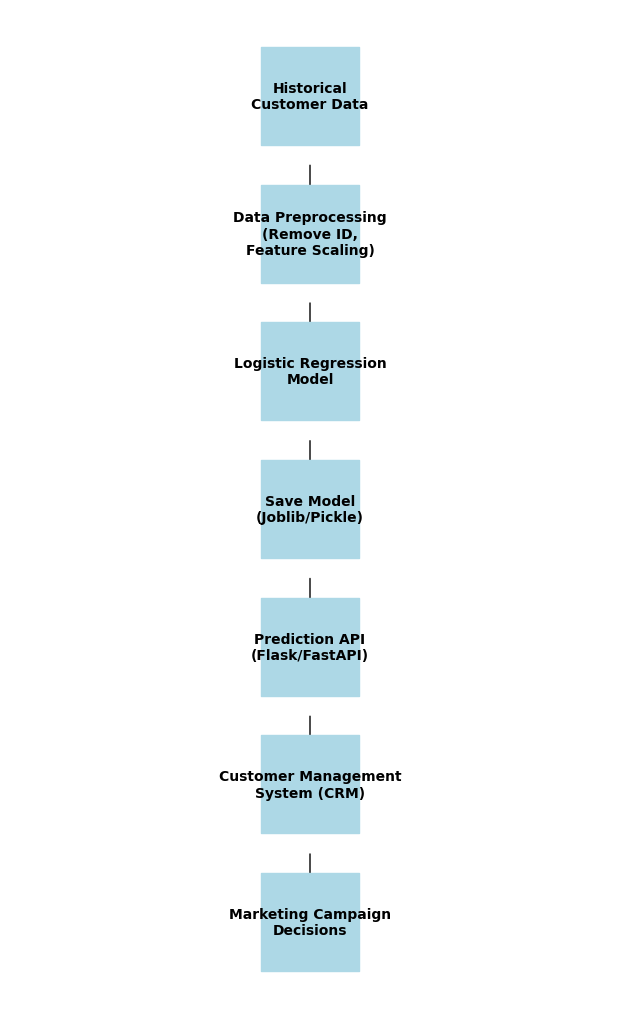

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Create directed graph
G = nx.DiGraph()

nodes = [
    "Historical\nCustomer Data",
    "Data Preprocessing\n(Remove ID,\nFeature Scaling)",
    "Logistic Regression\nModel",
    "Save Model\n(Joblib/Pickle)",
    "Prediction API\n(Flask/FastAPI)",
    "Customer Management\nSystem (CRM)",
    "Marketing Campaign\nDecisions"
]

# Add nodes and edges
G.add_nodes_from(nodes)

for i in range(len(nodes) - 1):
    G.add_edge(nodes[i], nodes[i + 1])

# Arrange nodes vertically
pos = {nodes[i]: (0, -i) for i in range(len(nodes))}

plt.figure(figsize=(6, 10))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=5000,
    node_color="lightblue",
    node_shape="s",
    arrows=True,
    font_size=10,
    font_weight="bold"
)

plt.axis("off")
plt.show()

**Step 1: Train the Model**

Train the Logistic Regression model using the historical customer transaction data after preprocessing and feature scaling.

Activities:

- Remove the ID_code column.
- Split the dataset into training and testing sets.
- Apply feature scaling using StandardScaler.
- Train the Logistic Regression model with class_weight='balanced'.
- Evaluate the model using Recall, Precision, F1-score, ROC-AUC, and the confusion matrix.

**Step 2: Save the Trained Model**

Once the model performs satisfactorily, save both the trained model and the fitted scaler so they can be reused without retraining.

import joblib

joblib.dump(model, "customer_transaction_model.pkl")

joblib.dump(scaler, "scaler.pkl")

**Saving the preprocessing objects ensures that new customer data is transformed in the same way as the training data**.

**Step 3: Build a Prediction API**

Develop a REST API using a framework such as Flask or FastAPI.

The API should:

- Receive customer feature values as input.
- Apply the saved feature scaler.
- Load the trained Logistic Regression model.
- Predict the probability of a future transaction.
- Return the predicted class (Transaction or No Transaction) along with the probability score.

**Step 4: Integrate with Business Systems**

The prediction API can be integrated into the bank's Customer Relationship Management (CRM) or marketing platform.

Whenever new customer data becomes available:

- Customer information is sent to the prediction API.
- The model calculates the transaction probability.
- Customers with a high probability of making a transaction are identified.
- The marketing team uses these predictions to target promotional campaigns and personalized offers.

**Step 5: Deploy the Application**

The prediction service can be deployed on cloud platforms such as:

- Amazon Web Services (AWS)
- Microsoft Azure
- Google Cloud Platform (GCP)

The deployment should include:

- Secure API endpoints.
- Authentication and authorization.
- Logging of prediction requests.
- Error handling and monitoring.

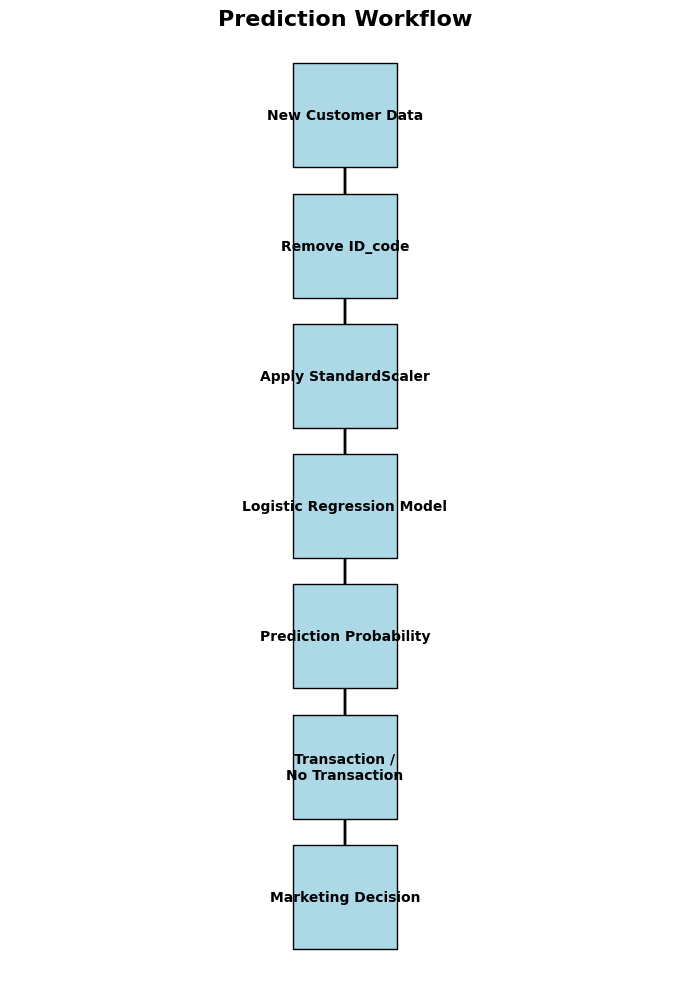

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Workflow nodes
nodes = [
    "New Customer Data",
    "Remove ID_code",
    "Apply StandardScaler",
    "Logistic Regression Model",
    "Prediction Probability",
    "Transaction /\nNo Transaction",
    "Marketing Decision"
]

# Add nodes
G.add_nodes_from(nodes)

# Add edges
for i in range(len(nodes) - 1):
    G.add_edge(nodes[i], nodes[i + 1])

# Vertical layout
pos = {node: (0, -i) for i, node in enumerate(nodes)}

# Plot
plt.figure(figsize=(7, 10))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=5500,
    node_color="lightblue",
    node_shape="s",
    edgecolors="black"
)

# Draw edges
nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    arrowsize=50,
    arrowstyle="-|>",
    width=2
)

# Draw labels
nx.draw_networkx_labels(
    G, pos,
    font_size=10,
    font_weight="bold"
)

plt.title("Prediction Workflow", fontsize=16, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

**Step 6: Model Monitoring**

After deployment, the model should be monitored continuously to ensure consistent performance.

Performance Metrics

Monitor:

- Recall
- Precision
- F1-score
- ROC-AUC
- Confusion Matrix
- Matthews Correlation Coefficient (MCC)

Recall should receive particular attention because the primary objective is to identify customers who are likely to make future transactions.

**Step 7: Business Monitoring**

In addition to technical metrics, business outcomes should also be monitored.

Examples include:

- Campaign response rate.
- Number of correctly identified transaction customers.
- Marketing conversion rate.
- Return on Investment (ROI).
- Customer engagement metrics.

These measures help determine whether the deployed model is delivering business value.

**Summary**

The selected Logistic Regression model with class_weight='balanced' is well-suited for deployment using a **batch learning approach**. Customer data can be collected over a defined period (for example, monthly), processed in batches, and scored to identify customers who are likely to make future transactions. Continuous monitoring of model performance and business outcomes, together with periodic retraining, helps maintain prediction quality and supports effective customer-targeting strategies over time.

**Why Batch Learning?**

Dataset characteristics:
-	200,000 records
-	Historical customer data
-	Transaction prediction is not required in real time
-	Model retraining can be scheduled periodically

In banking and marketing applications, customer transaction propensity models are often updated:
-	Weekly
-	Monthly
-	Quarterly

rather than after every individual customer interaction

**Advantages** of Batch Learning

1. Simpler implementation
2. Easier monitoring and validation
3. More stable model performance
4. Allows retraining on large volumes of new customer data
5. Suitable for Logistic Regression and XGBoost

**Why Not Online Learning?**

Online learning updates the model continuously as new data arrives. Customer transaction behaviour does not change every second. Continuous updates increase operational complexity.

The proposed system is best suited for a batch learning approach. Customer transaction data can be collected over a defined period and the model can be retrained periodically using newly available data. Batch learning provides stable performance, simpler deployment, and easier model monitoring compared to online learning. Since customer transaction prediction does not require real-time model updates, batch learning is a practical and cost-effective solution for deployment in a banking environment.



**Future Enhancements**

Although the developed Logistic Regression model achieved strong performance in identifying potential transaction customers, there are several opportunities to further improve the predictive framework and its practical applicability.

1. Advanced Class Imbalance Handling

    The dataset is highly imbalanced, with only about 10% of observations belonging to the transaction class. Future work could evaluate techniques such as SMOTE, ADASYN, or hybrid sampling methods to improve minority-class prediction while maintaining an acceptable balance between precision and recall.

2. Feature Engineering

    Since the dataset contains anonymized numerical features, additional feature engineering techniques, such as feature interactions, polynomial features, or dimensionality reduction methods like Principal Component Analysis (PCA), could be explored to improve predictive performance.

3. Threshold Optimization

    The default classification threshold of 0.5 may not be optimal for this business problem. Future work could identify an optimal threshold that maximizes recall while maintaining an acceptable level of precision, better aligning the model with business objectives.

#### References

1. Customer Transaction Prediction Dataset given by datamites https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1003-CustTransPred.zip

   
   The dataset used for model development and evaluation was given by Datamites.

2. Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow by Aurélien Géron

   
   Referenced for machine learning concepts and model evaluation techniques.

3. Scikit-learn Documentation

   
   Used for Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, preprocessing, and model evaluation.

4. XGBoost Documentation

   
   Used for implementing the XGBoost classifier.

5.	Matplotlib Documentation

  
    Used for visualizations and ROC-AUC curve plotting.

6. Networkx
   
   https://www.geeksforgeeks.org/python/python-visualize-graphs-generated-in-networkx-using-matplotlib/








